## Cél

Ez a notebook a `lgbm_solusdt_l_fw60_2021` modell `sample_train_valid.parquet` állományát elemzi. A fókusz azon van, hogy a modell train és valid időszakokban hogyan viselkedik, mennyire követi a folytonos targetet, és milyen minőségű regressziós jelet ad.

Vizsgált területek: napi átlagos modellkimenet és fact target időbeli alakulása, train-valid teljesítménymutatók, predikció-target kapcsolat, valamint regressziós best-practice diagnosztikák.

**Kapcsolódó dokumentáció:**
- Módszertan: `_doc_/5000_modelling.md`
- Kód-dokumentáció: `_doc_/5500_hyper_param_search.md`
- Kód-dokumentáció: `_doc_/6100_calibration.md`

**Asset:** SOLUSDT | **Granularitás:** 1h yearly sample | **Dátum:** 2026-06-20


In [1]:
from __future__ import annotations

import importlib.util
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

_root = Path.cwd()
if _root.name == "_doc_":
    _root = _root.parent

sys.path.insert(0, str(_root))
sys.path.insert(0, str(_root / "src"))

from analyst.table_formatting import display_analysis_table

helper_path = _root / "analyst" / "5600_model_2021_train_valid_analysis.py"
spec = importlib.util.spec_from_file_location("model_2021_train_valid_analysis_5600", helper_path)
h = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = h
assert spec.loader is not None
spec.loader.exec_module(h)

CQ_COLORS = {
    "blue": "#1696d2",
    "black": "#000000",
    "gray_dark": "#353535",
    "gray": "#696969",
    "gray_light": "#d2d2d2",
    "yellow": "#fdbf11",
    "orange": "#f15a24",
    "red": "#ec008b",
}
CQ_SEQUENCE = [
    CQ_COLORS["blue"], CQ_COLORS["yellow"], CQ_COLORS["orange"],
    CQ_COLORS["gray"], CQ_COLORS["red"],
]

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.figsize": (10, 5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": CQ_COLORS["gray"],
        "axes.labelcolor": CQ_COLORS["gray_dark"],
        "xtick.color": CQ_COLORS["gray_dark"],
        "ytick.color": CQ_COLORS["gray_dark"],
        "grid.color": CQ_COLORS["gray_light"],
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "legend.frameon": False,
    },
)
sns.set_palette(CQ_SEQUENCE)

cache_dir = h.ensure_cache(_root)
pred_df = h.load_cv_predictions(_root)
fold_metrics_df = h.load_fold_metrics(_root)
metadata_snapshot = h.load_metadata_snapshot(_root)
daily_df = h.daily_profile(pred_df)
split_metrics_df = h.split_summary_metrics(pred_df)
bins_df = h.prediction_bins(pred_df)
residual_df = h.residual_summary(pred_df)
scatter_df = h.scatter_sample(pred_df)
commentary_lines = h.commentary_lines(split_metrics_df, fold_metrics_df)

daily_full_df = (
    pred_df.groupby(["cv_fold", "date", "segment"]) \
        .agg(pred_mean=("pred", "mean"), target_mean=(h.TARGET_COL, "mean"), rows=("pred", "size")) \
        .reset_index()
)
model_summary_df = pd.DataFrame([
    {
        "model_id": metadata_snapshot["model_id"],
        "rows": len(pred_df[pred_df['segment'] == 'valid']),
        "days": pred_df['date'].nunique(),
        "folds": pred_df['cv_fold'].nunique(),
        "target_col": metadata_snapshot['target_col'],
        "prediction_col": metadata_snapshot['pred_col'],
    }
])
fold_overview_df = pd.DataFrame([
    {
        "fold": int(fold),
        "valid_week_count": len(metadata_snapshot['fold_week_assignments'][str(fold)]),
        "valid_start": metadata_snapshot['fold_week_assignments'][str(fold)][0]['start'],
        "valid_end": metadata_snapshot['fold_week_assignments'][str(fold)][-1]['end'],
    }
    for fold in sorted(pred_df['cv_fold'].unique())
])

display(Markdown(
    "**Megjegyzés:** a `pred_long` oszlop neve probability-szerű, de ennél a modellnél regressziós kimenet, "
    "ugyanazon a log-return skálán, mint a `long_mfe_fw60` target. A validációs ábrák ezért predikció-vs-target regressziós olvasatban értendők."
))


**Megjegyzés:** a `pred_long` oszlop neve probability-szerű, de ennél a modellnél regressziós kimenet, ugyanazon a log-return skálán, mint a `long_mfe_fw60` target. A validációs ábrák ezért predikció-vs-target regressziós olvasatban értendők.

## Input és fold-struktúra

**Mi ez.** A modellhez tartozó train-valid sample alapjellemzői és a foldokra bontott validációs hetek.

**Forrás.** `artifacts/lgbm_solusdt_l_fw60_2021/sample_train_valid.parquet`, `metadata.json`.

**Értelmezés.** A sample 2021 teljes évét hourly mintában fedi le. A train-valid szeparáció nem egyetlen blokk, hanem foldonként más valid hét-kiosztás, ezért a napi ábrákat foldonként kell olvasni.


In [2]:
#| label: tbl-model-2021-sample-summary
#| tbl-cap: "A 2021-es modell sample-jének alapösszefoglalója"

display_analysis_table(model_summary_df)
display_analysis_table(fold_overview_df)

display(Markdown(
    "**Értelmezés:** a sample 8760 hourly sort tartalmaz, vagyis 2021 minden órájából egy megfigyelést. "
    "A valid hetek foldonként más helyre esnek, ezért ugyanaz a naptári nap train az egyik foldban és valid a másikban."
))


model_id,rows,days,folds,target_col,prediction_col
lgbm_solusdt_l_fw60_2021,8760,365,4,long_mfe_fw60,pred_long


fold,valid_week_count,valid_start,valid_end
1,16,2021-01-18,2021-12-19
2,12,2021-01-25,2022-01-02
3,12,2021-01-04,2021-12-12
4,12,2021-01-11,2021-12-26


**Értelmezés:** a sample 8760 hourly sort tartalmaz, vagyis 2021 minden órájából egy megfigyelést. A valid hetek foldonként más helyre esnek, ezért ugyanaz a naptári nap train az egyik foldban és valid a másikban.

## Napi prob és fact target foldonként

**Mi ez.** Napi átlagos modellkimenet és napi átlagos fact target foldonként, a valid időszakok háttérsávozásával.

**Forrás.** Foldonként újrafitelt CV predikciók; napi aggregáció a `pred` és `long_mfe_fw60` oszlopokra.

**Értelmezés.** Ez mutatja meg, hogy a modell napi szinten mennyire követi a targetet, és hogy a validációs hetek alatt másképp viselkedik-e, mint train környezetben.


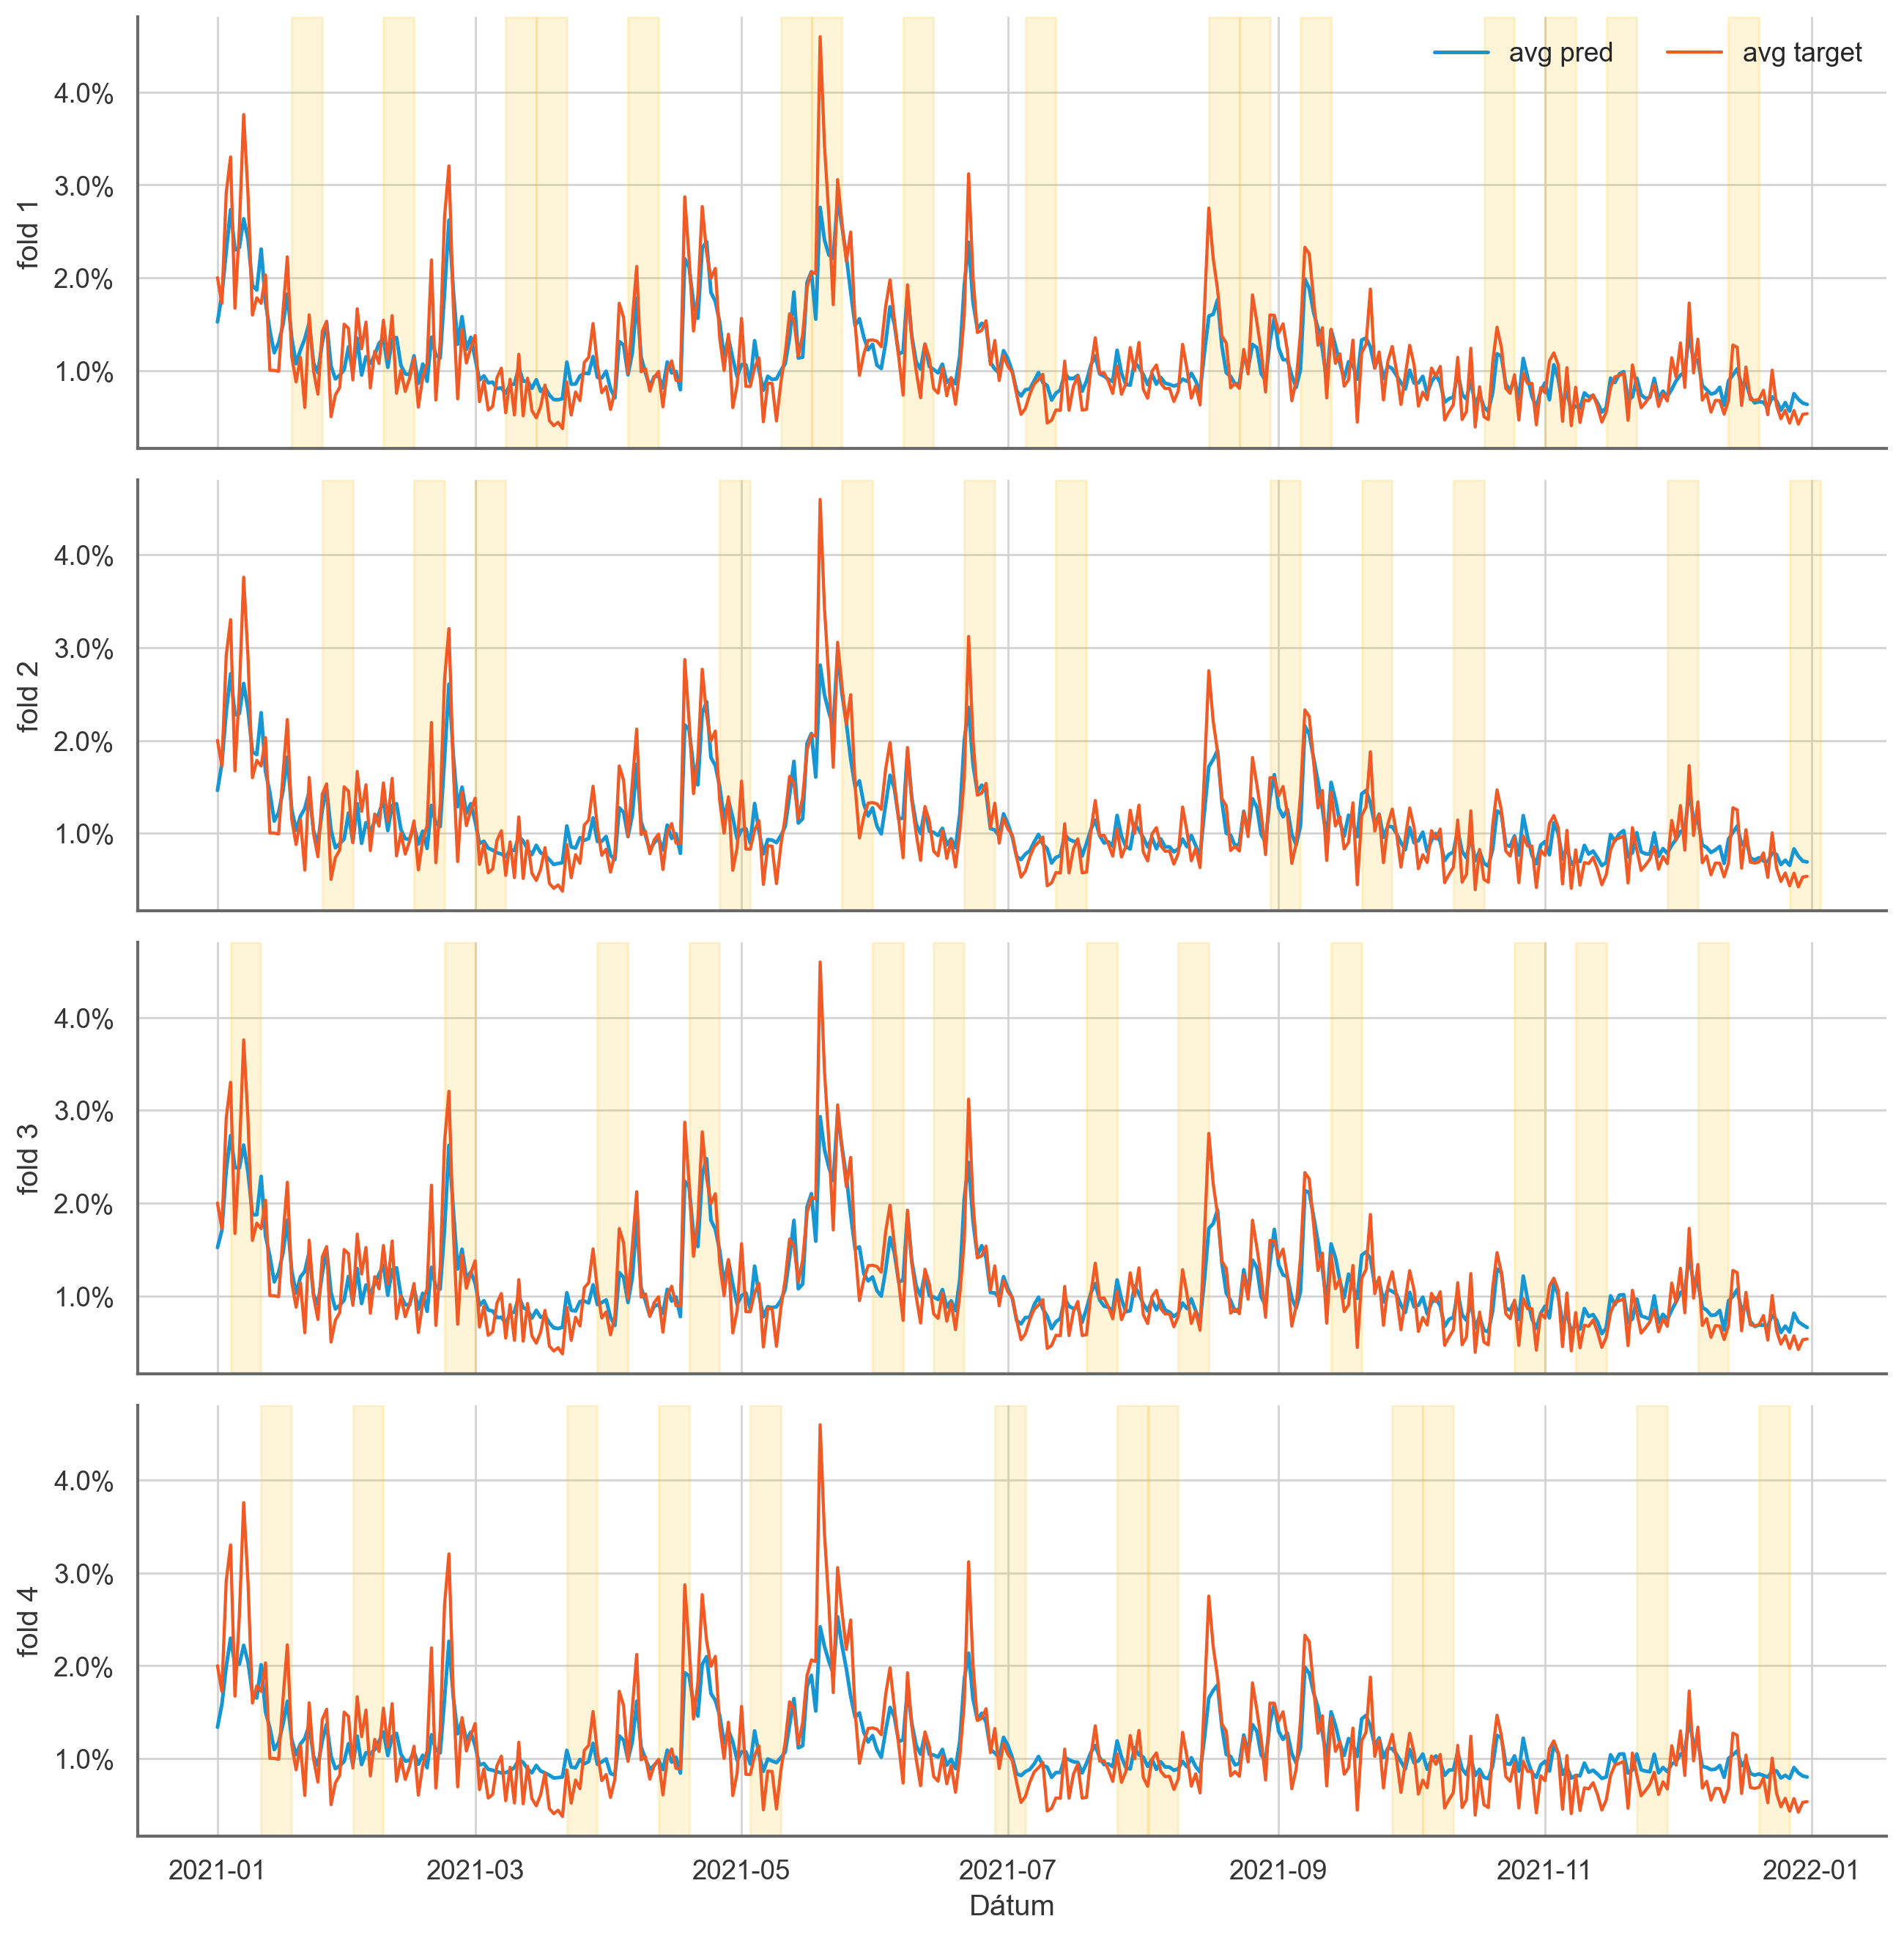

**Értelmezés:** a kék és narancs görbe együttmozgása pozitív, de nem szoros. A valid hetek alatt több helyen látszik törés vagy ellaposodás, vagyis a modell követi a target rezsimjét, de zajos és nem stabil napi pontbecslő.

In [3]:
#| label: fig-model-2021-daily-pred-target-by-fold
#| fig-cap: "Napi átlagos predikció és target foldonként, valid időszakok sávos jelölésével"
#| fig-alt: "Four stacked time-series panels, one per fold, with daily mean prediction and target and shaded validation weeks."

folds = sorted(pred_df['cv_fold'].unique())
fig, axes = plt.subplots(len(folds), 1, figsize=(11, 2.8 * len(folds)), sharex=True)
if len(folds) == 1:
    axes = [axes]

for ax, fold in zip(axes, folds):
    sub = daily_full_df[daily_full_df['cv_fold'] == fold].sort_values('date')
    ax.plot(sub['date'], sub['pred_mean'], color=CQ_COLORS['blue'], linewidth=1.5, label='avg pred')
    ax.plot(sub['date'], sub['target_mean'], color=CQ_COLORS['orange'], linewidth=1.3, label='avg target')
    for start, end in h.fold_valid_spans(metadata_snapshot, int(fold)):
        ax.axvspan(start, end, color=CQ_COLORS['yellow'], alpha=0.16)
    ax.set_ylabel(f'fold {int(fold)}')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))

axes[0].legend(loc='upper right', ncol=2)
axes[-1].set_xlabel('Dátum')
plt.tight_layout()
plt.show()

display(Markdown(
    "**Értelmezés:** a kék és narancs görbe együttmozgása pozitív, de nem szoros. A valid hetek alatt több helyen látszik törés vagy ellaposodás, vagyis a modell követi a target rezsimjét, de zajos és nem stabil napi pontbecslő."
))


## Train és valid teljesítmény

**Mi ez.** Aggregált és foldonkénti regressziós teljesítménymutatók train és valid oldalon.

**Forrás.** A legjobb 2021-es paraméterekkel újrafitelt 4-fold CV predikciók.

**Értelmezés.** Regressziós best practice szerint RMSE, MAE és R² együtt ad képet: az első kettő a hibaméretet mutatja, az utolsó azt, hogy a target varianciájából mennyit fog meg a modell.


In [4]:
#| label: tbl-model-2021-split-metrics
#| tbl-cap: "Összesített train és valid regressziós metrikák"

display_analysis_table(split_metrics_df)

display(Markdown(
    f"**Értelmezés:** a valid oldali átlagos RMSE `{split_metrics_df.loc[split_metrics_df['segment']=='valid', 'rmse'].iloc[0]:.4f}`, "
    f"ami gyakorlatilag azonos a train oldali `{split_metrics_df.loc[split_metrics_df['segment']=='train', 'rmse'].iloc[0]:.4f}` értékkel. "
    "A különbség kicsi, ezért a modell nem tűnik súlyosan overfiteltnek, viszont az R² így is mérsékelt marad."
))


segment,rows,pred_mean,target_mean,rmse,mae,r2,corr
train,26280,0.011,0.011,0.013,0.008,0.192,0.445
valid,8760,0.011,0.011,0.013,0.008,0.166,0.409


**Értelmezés:** a valid oldali átlagos RMSE `0.0130`, ami gyakorlatilag azonos a train oldali `0.0128` értékkel. A különbség kicsi, ezért a modell nem tűnik súlyosan overfiteltnek, viszont az R² így is mérsékelt marad.

In [5]:
#| label: tbl-model-2021-fold-metrics
#| tbl-cap: "Foldonkénti train-valid regressziós teljesítmény"

display_analysis_table(fold_metrics_df)

display(Markdown(
    "**Értelmezés:** a valid teljesítmény foldonként eltér, vagyis az általánosíthatóság időszakfüggő. Ez megfelel annak a képnek, hogy a 2021-es targeten belül is több rezsim váltakozik."
))


fold,best_iteration,train_rmse,valid_rmse,train_mae,valid_mae,train_r2,valid_r2,train_n,valid_n
1,2988.00%,0.012,0.015,0.008,0.009,0.214,0.180,6000,2760
2,486.00%,0.013,0.012,0.008,0.008,0.191,0.135,6792,1968
3,2085.00%,0.012,0.014,0.008,0.009,0.199,0.201,6744,2016
4,209.00%,0.014,0.010,0.009,0.007,0.170,0.056,6744,2016


**Értelmezés:** a valid teljesítmény foldonként eltér, vagyis az általánosíthatóság időszakfüggő. Ez megfelel annak a képnek, hogy a 2021-es targeten belül is több rezsim váltakozik.

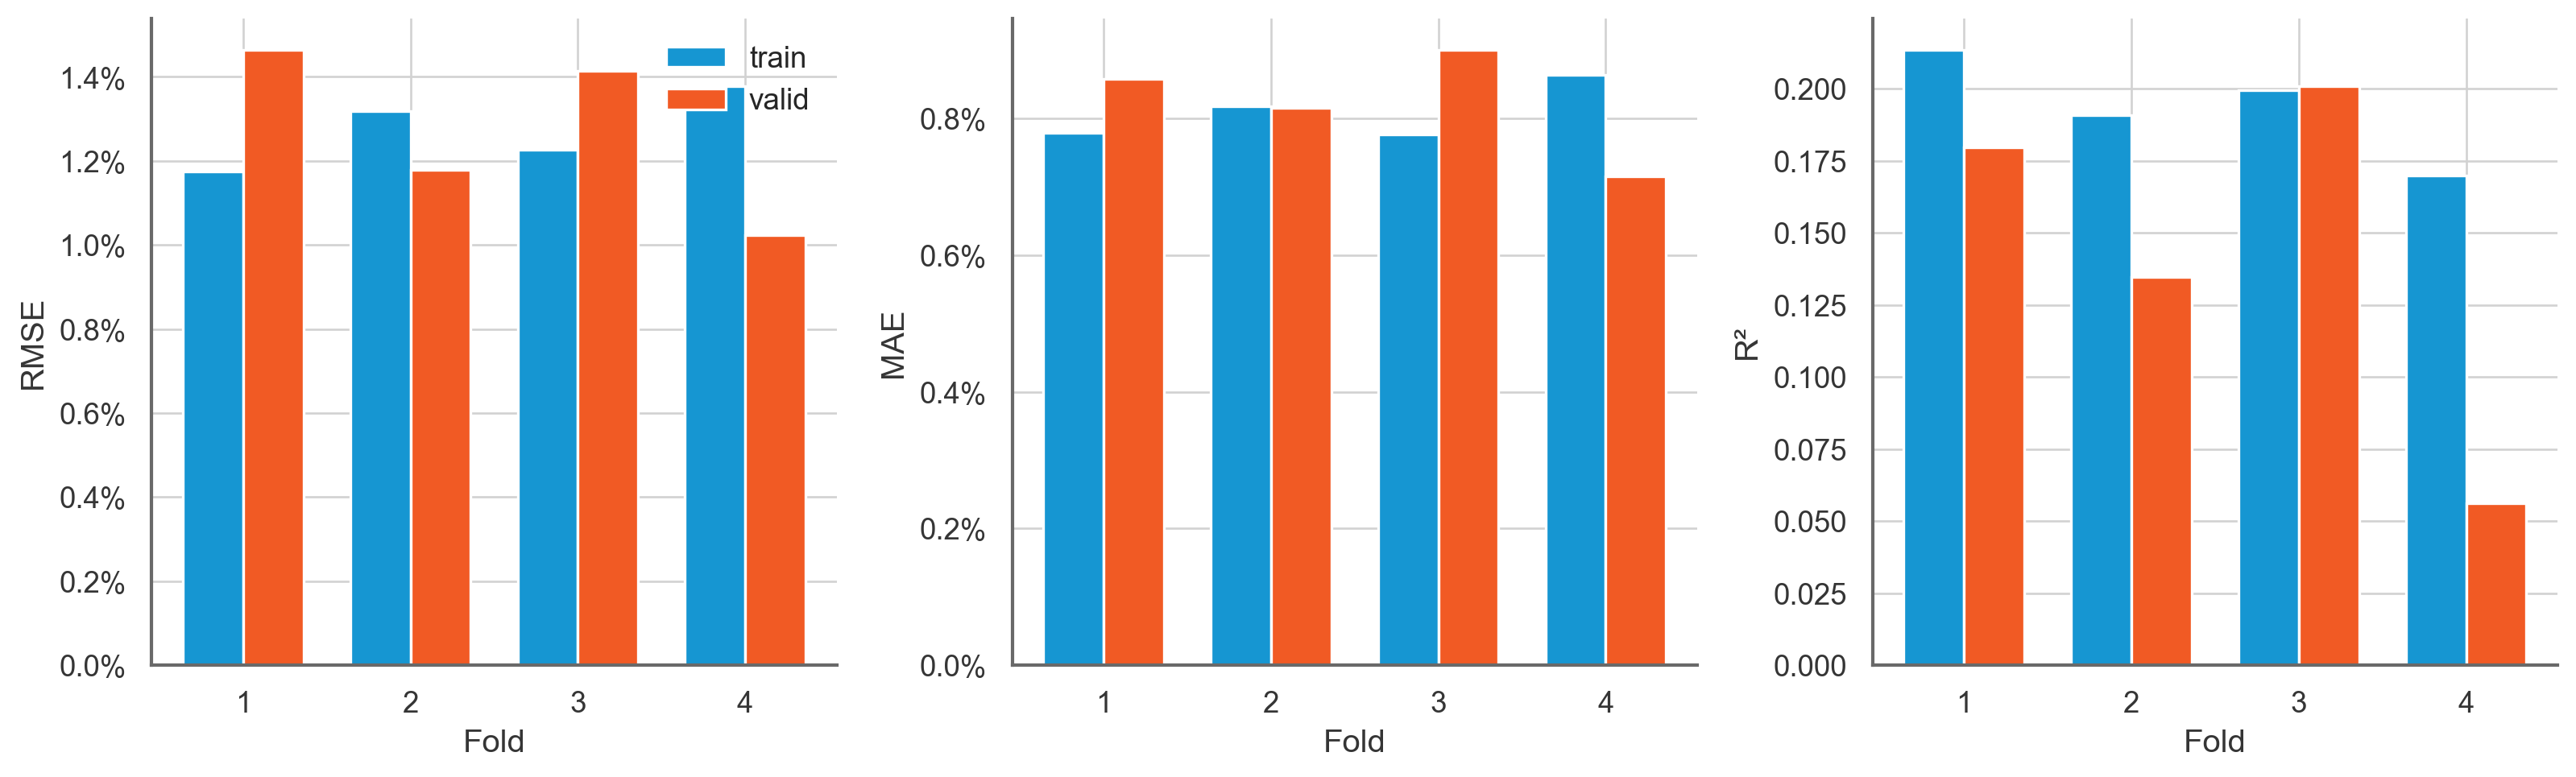

**Értelmezés:** az 1-es és 3-as fold valid oldalon nehezebb, a 2-es és 4-es könnyebb. A foldszórás fontosabb jelzés, mint az átlag egyetlen száma.

In [6]:
#| label: fig-model-2021-fold-performance
#| fig-cap: "Foldonkénti train-valid teljesítmény: RMSE, MAE és R²"
#| fig-alt: "Three-panel grouped bar chart comparing train and validation RMSE, MAE, and R2 by fold."

plot_df = fold_metrics_df.copy()
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
metrics = [('train_rmse', 'valid_rmse', 'RMSE'), ('train_mae', 'valid_mae', 'MAE'), ('train_r2', 'valid_r2', 'R²')]
for ax, (m_train, m_valid, label) in zip(axes, metrics):
    width = 0.36
    x = np.arange(len(plot_df))
    ax.bar(x - width / 2, plot_df[m_train], width=width, color=CQ_COLORS['blue'], label='train')
    ax.bar(x + width / 2, plot_df[m_valid], width=width, color=CQ_COLORS['orange'], label='valid')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['fold'].astype(str).tolist())
    ax.set_xlabel('Fold')
    ax.set_ylabel(label)
    if label != 'R²':
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
axes[0].legend(loc='upper right')
plt.tight_layout()
plt.show()

display(Markdown(
    "**Értelmezés:** az 1-es és 3-as fold valid oldalon nehezebb, a 2-es és 4-es könnyebb. A foldszórás fontosabb jelzés, mint az átlag egyetlen száma."
))


## Predikció és target kapcsolata

**Mi ez.** Predikció-vs-fact scatter train és valid oldalon. A referenciaegyenes az ideális `y = x` kapcsolatot mutatja.

**Forrás.** Foldonként újrafitelt train és valid predikciók.

**Értelmezés.** Ideális modell esetén a pontok szorosan a `y = x` egyenes köré ülnének. A szóródás szélessége közvetlenül mutatja, mennyire zajos a regressziós jel.


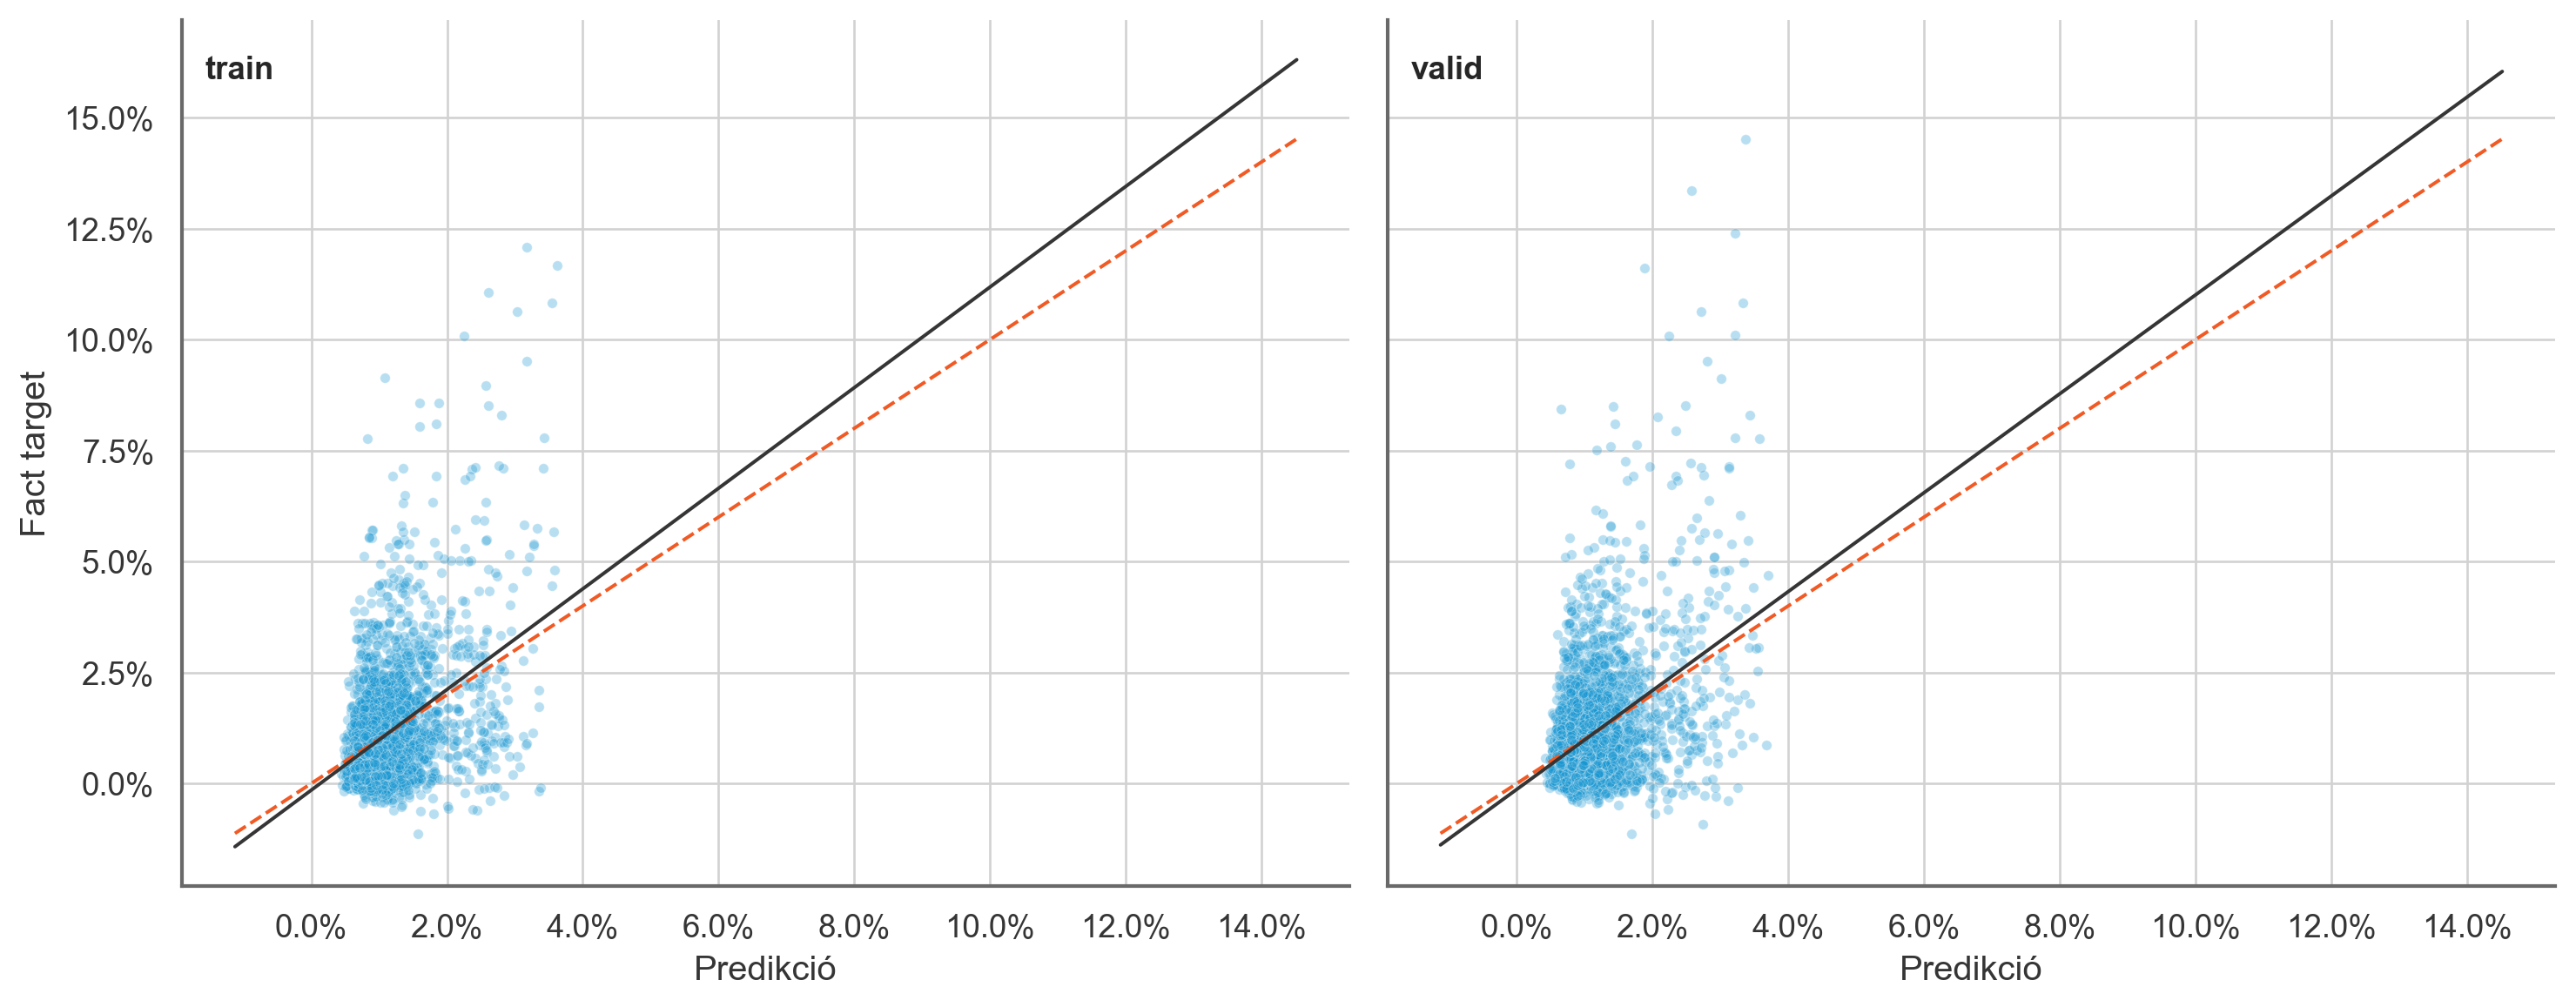

**Értelmezés:** a kapcsolat pozitív, de a pontfelhő széles. A valid panel még szórtabb, tehát a modell inkább irány- és rangsorjellegű információt hordoz, mint pontos értékbecslést.

In [7]:
#| label: fig-model-2021-pred-vs-target-scatter
#| fig-cap: "Predikció vs fact target train és valid oldalon, ideális y=x vonallal"
#| fig-alt: "Two scatter panels for train and validation predicted vs actual target with ideal diagonal line."

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0), sharex=True, sharey=True)
vmin = float(min(scatter_df['pred'].min(), scatter_df[h.TARGET_COL].min()))
vmax = float(max(scatter_df['pred'].max(), scatter_df[h.TARGET_COL].max()))
for ax, segment in zip(axes, ['train', 'valid']):
    sub = scatter_df[scatter_df['segment'] == segment]
    sns.scatterplot(data=sub, x='pred', y=h.TARGET_COL, s=12, alpha=0.30, color=CQ_COLORS['blue'], ax=ax)
    ax.plot([vmin, vmax], [vmin, vmax], color=CQ_COLORS['orange'], linestyle='--', linewidth=1.2)
    if len(sub) > 1:
        fit = np.polyfit(sub['pred'], sub[h.TARGET_COL], 1)
        xs = np.linspace(vmin, vmax, 100)
        ax.plot(xs, fit[0] * xs + fit[1], color=CQ_COLORS['gray_dark'], linewidth=1.2)
    ax.set_xlabel('Predikció')
    ax.set_ylabel('Fact target')
    ax.text(0.02, 0.96, segment, transform=ax.transAxes, ha='left', va='top', fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
plt.tight_layout()
plt.show()

display(Markdown(
    "**Értelmezés:** a kapcsolat pozitív, de a pontfelhő széles. A valid panel még szórtabb, tehát a modell inkább irány- és rangsorjellegű információt hordoz, mint pontos értékbecslést."
))


## Regressziós best-practice diagnosztikák

**Mi ez.** Predikciós bin-ek menti átlagos target és residual összefoglaló train-valid bontásban.

**Forrás.** A foldonként újrafitelt CV predikciók kvantilis binelése és residual számítása.

**Értelmezés.** A binelt ábra azt mutatja, hogy nagyobb predikcióhoz ténylegesen nagyobb realizált target társul-e. Ez jó regressziós sanity check időszakos modelleknél.


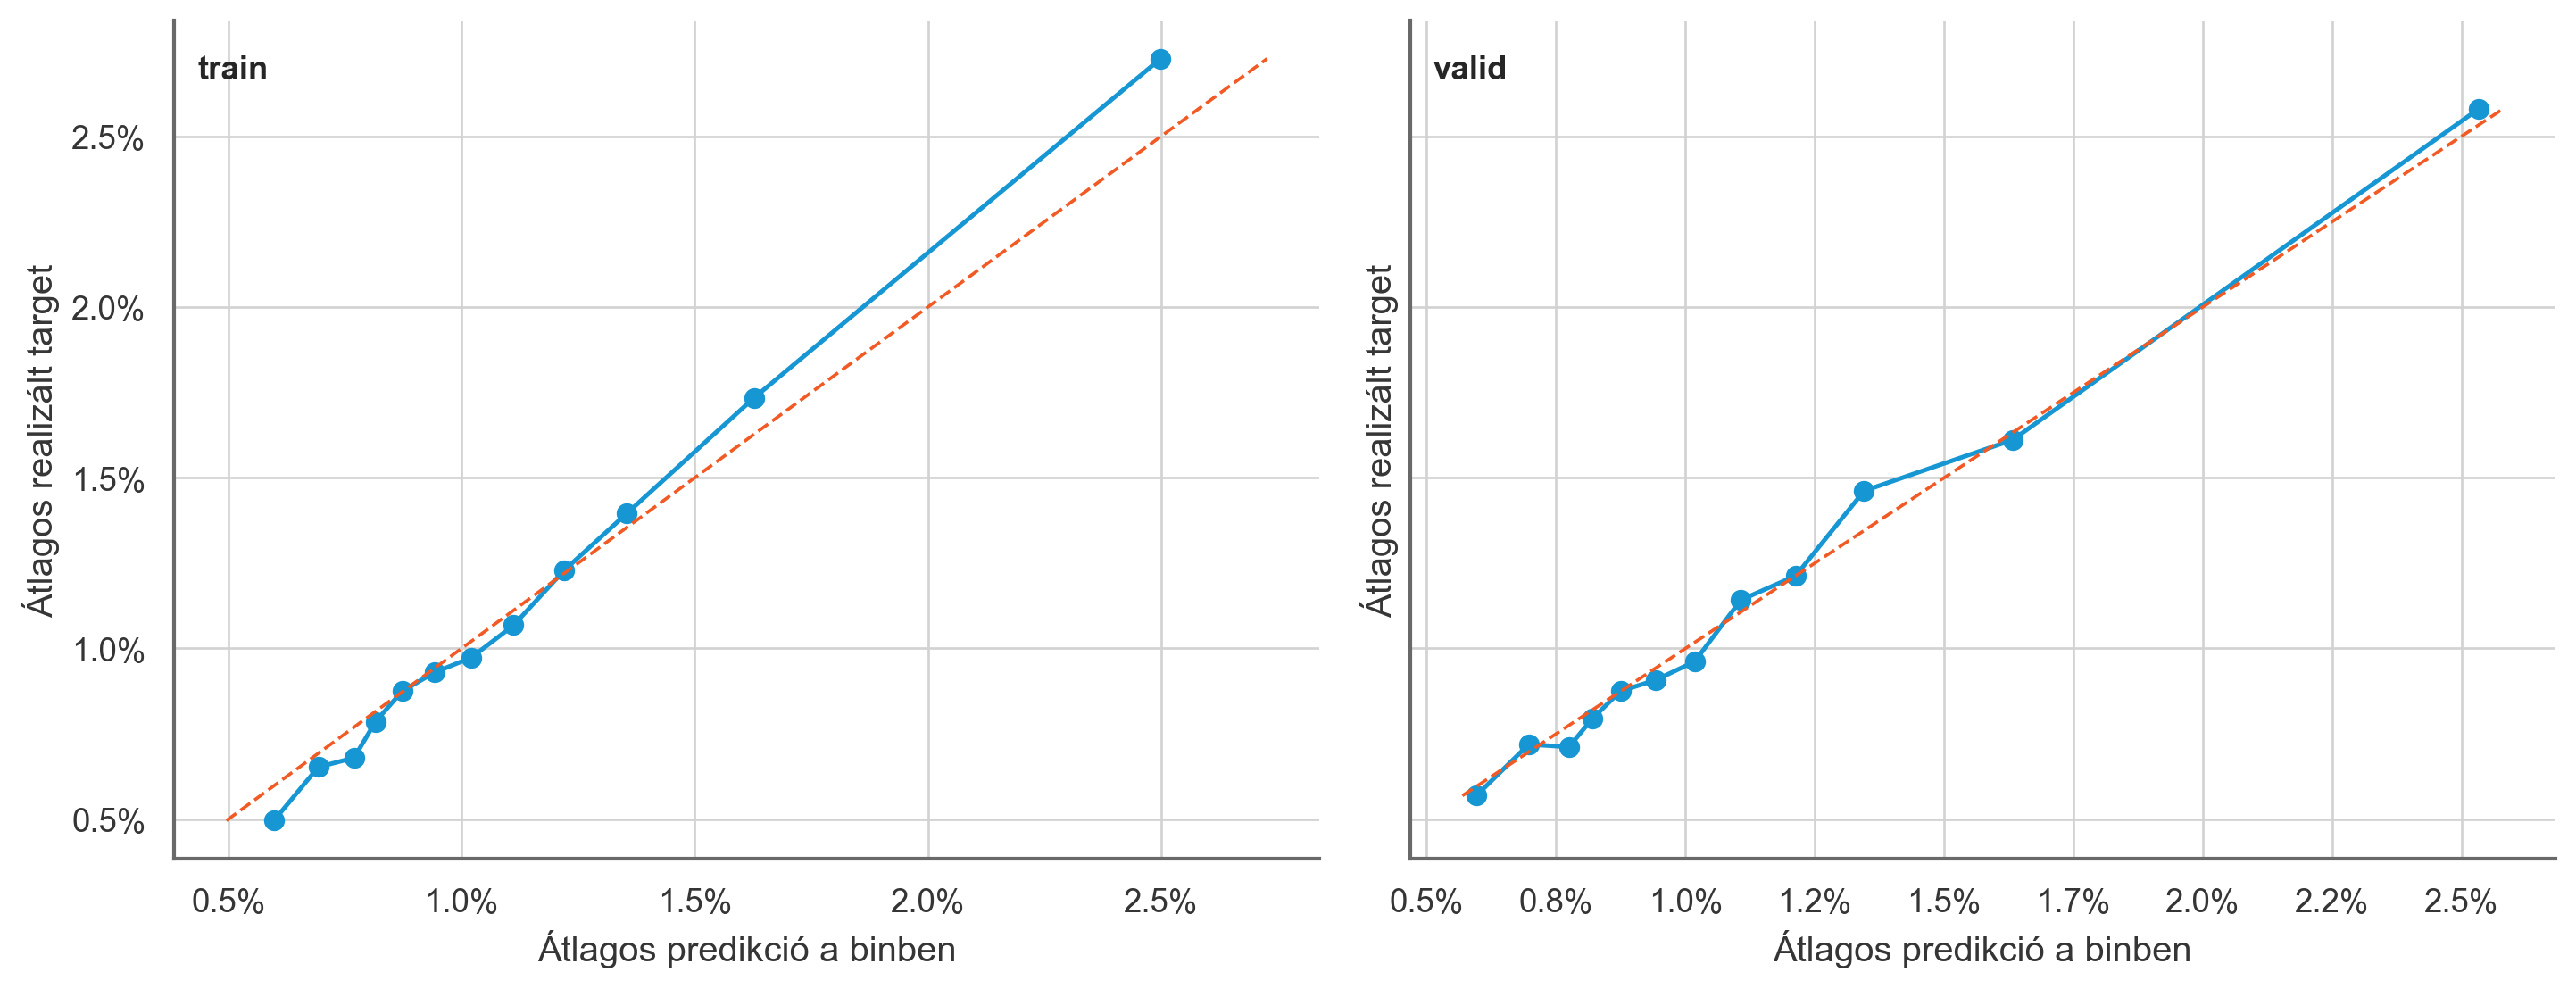

**Értelmezés:** a görbe emelkedő, tehát a magasabb predikcióhoz átlagosan magasabb target társul. Ez jó jel a modell rangsorolási hasznosságára nézve, még ha a pontbecslés pontossága közepes is.

In [8]:
#| label: fig-model-2021-binned-prediction-profile
#| fig-cap: "Predikciós bin-ek szerinti átlagos predikció és realizált target"
#| fig-alt: "Binned prediction profile showing average predicted and realized target by split."

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8), sharey=True)
for ax, segment in zip(axes, ['train', 'valid']):
    sub = bins_df[bins_df['segment'] == segment].reset_index(drop=True)
    ax.plot(sub['pred_mean'], sub['target_mean'], marker='o', color=CQ_COLORS['blue'])
    lo = float(min(sub['pred_mean'].min(), sub['target_mean'].min()))
    hi = float(max(sub['pred_mean'].max(), sub['target_mean'].max()))
    ax.plot([lo, hi], [lo, hi], linestyle='--', color=CQ_COLORS['orange'], linewidth=1.1)
    ax.set_xlabel('Átlagos predikció a binben')
    ax.set_ylabel('Átlagos realizált target')
    ax.text(0.02, 0.96, segment, transform=ax.transAxes, ha='left', va='top', fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
plt.tight_layout()
plt.show()

display(Markdown(
    "**Értelmezés:** a görbe emelkedő, tehát a magasabb predikcióhoz átlagosan magasabb target társul. Ez jó jel a modell rangsorolási hasznosságára nézve, még ha a pontbecslés pontossága közepes is."
))


segment,resid_mean,resid_std,resid_q05,resid_median,resid_q95
train,-0.000,0.013,-0.021,0.003,0.013
valid,0.000,0.013,-0.021,0.003,0.013


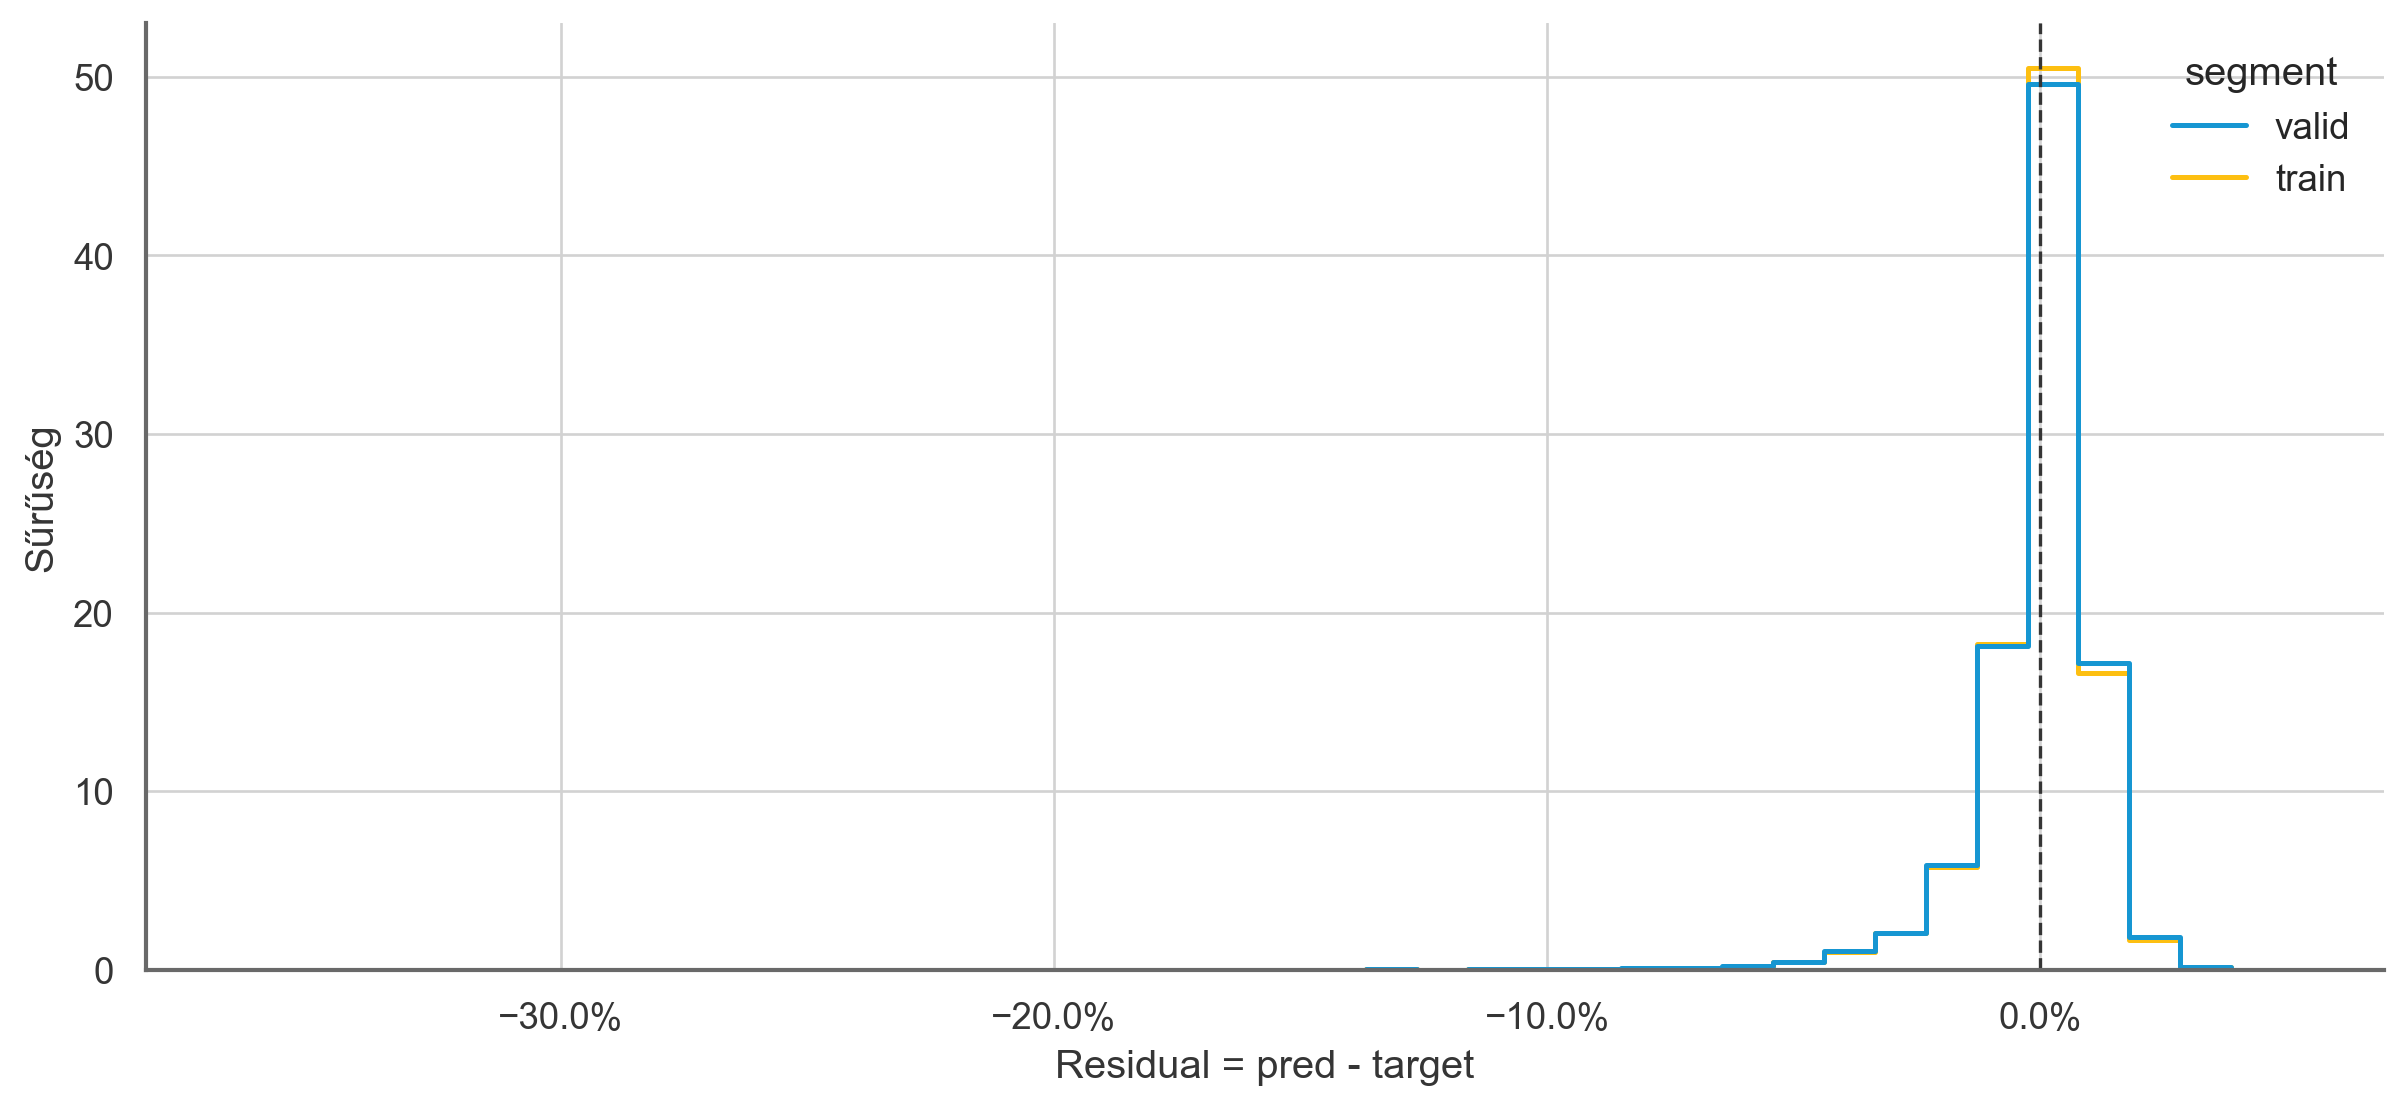

**Értelmezés:** a residual eloszlás középre húz, de széles. A valid eloszlás valamivel szélesebb, ami összhangban van a gyengébb out-of-sample pontbecsléssel.

In [9]:
#| label: tbl-model-2021-residual-summary
#| tbl-cap: "Residual összefoglaló train és valid oldalon"

display_analysis_table(residual_df)

fig, ax = plt.subplots(figsize=(10.2, 4.8))
sns.histplot(data=pred_df, x=pred_df['pred'] - pred_df[h.TARGET_COL], hue='segment', bins=40, stat='density', common_norm=False, element='step', fill=False, ax=ax)
ax.axvline(0.0, color=CQ_COLORS['gray_dark'], linestyle='--', linewidth=1.0)
ax.set_xlabel('Residual = pred - target')
ax.set_ylabel('Sűrűség')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
plt.tight_layout()
plt.show()

display(Markdown(
    "**Értelmezés:** a residual eloszlás középre húz, de széles. A valid eloszlás valamivel szélesebb, ami összhangban van a gyengébb out-of-sample pontbecsléssel."
))


## Értelmezés a 2021-es modellhez

**Mi ez.** Rövid, eredményalapú olvasat a fenti train-valid és regressziós diagnosztikákból.

**Forrás.** A notebookban kiszámolt foldonkénti CV predikciók és metrikák.

**Értelmezés.** Itt az a cél, hogy a fenti ábrákból gyakorlati modellolvasat legyen: mennyire stabil a modell, mennyire használható rangsorolásra, és hol vannak a gyenge pontjai.


In [10]:
#| label: tbl-model-2021-interpretation
#| tbl-cap: "Értelmezési pontok a 2021-es modellről"

bullet_md = "\n".join(f"- {line}" for line in commentary_lines)
display(Markdown(
    "**Modellezési olvasat**\n\n"
    "A 2021-es modell nem mutat klasszikus durva overfittinget, mert a train és valid hiba közel van egymáshoz. "
    "Ugyanakkor a valid oldali R² mérsékelt, és a scatter alapján a predikció-target kapcsolat zajos marad.\n\n"
    "**Gyakorlati következmények:**\n"
    f"{bullet_md}\n\n"
    "**Döntési irány:** ez a modell valószínűleg inkább rangsorolási vagy threshold-alapú szelekcióra használható, mint pontos target-becslésre. "
    "A kalibrációs és threshold-döntésekhez ezért a validációs foldok közti szórást ugyanannyira kell figyelni, mint az átlagos hibamértéket."
))


**Modellezési olvasat**

A 2021-es modell nem mutat klasszikus durva overfittinget, mert a train és valid hiba közel van egymáshoz. Ugyanakkor a valid oldali R² mérsékelt, és a scatter alapján a predikció-target kapcsolat zajos marad.

**Gyakorlati következmények:**
- A validációs átlagos RMSE `0.0130`, a train oldali `0.0128`; a két oldal közel van egymáshoz, ezért a modell nem látszik durván overfiteltnek.
- A validációs R² csak `0.166`, ezért a modell jelet fog, de a folytonos target varianciájának jelentős része továbbra is megmagyarázatlan.
- A legjobb valid fold a `4`, a leggyengébb a `1`; tehát a teljesítmény szemmel láthatóan rezsim- és időszakfüggő.
- A predikció-target kapcsolat pozitív, de zajos. Ez használható rangsorolási jellegű kimenetre, de nem tekinthető pontos pontbecslő regressziónak.

**Döntési irány:** ez a modell valószínűleg inkább rangsorolási vagy threshold-alapú szelekcióra használható, mint pontos target-becslésre. A kalibrációs és threshold-döntésekhez ezért a validációs foldok közti szórást ugyanannyira kell figyelni, mint az átlagos hibamértéket.